# PySlice Axis-Parallel Slicing Performance Benchmark

This notebook tests the performance of PySlice axis-parallel slicing on tiny neural networks, comparing CPU vs GPU performance in Google Colab.

We'll measure how fast PySlice can perform axis-parallel slicing with 100 samples per parameter on neural networks with different parameter counts. This is particularly interesting because axis-parallel slicing scales linearly with the number of parameters (N parameters × 100 samples = total evaluations), unlike random direction slicing which has fixed evaluation count.

In [10]:
# !git clone https://github.com/joeseegtatz/loss-slicer.git
# !cd loss-slicer/ && pip install -r requirements.txt
# !cd loss-slicer/ && pip install .

In [11]:
# Import required libraries
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from examples.example_models import generate_sample_data
from pysclice.core.model_wrapper import ModelWrapper
from pysclice.slicers.axis_parallel_slicer import AxisParallelSlicer

# Check available devices
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch version: 2.8.0
CUDA available: False


In [12]:
def create_mlp(layer_sizes):
    """Create MLP with specified layer sizes."""
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        if i < len(layer_sizes) - 2:
            layers.append(torch.nn.ReLU())
    return torch.nn.Sequential(*layers)

# Test the function by creating sample models and showing parameter counts
test_configs = [
    ("4 params", [3, 1]),
    ("8 params", [3, 2, 1]),
    ("12 params", [3, 3, 1]),
]

print("Testing model configurations:")
for name, config in test_configs:
    test_model = create_mlp(config)
    test_params = sum(p.numel() for p in test_model.parameters())
    total_evaluations = test_params * 100  # 100 samples per parameter
    print(f"  {name}: {test_params} parameters → {total_evaluations} evaluations (config: {config})")

print("Model creation function works correctly!")

Testing model configurations:
  4 params: 4 parameters → 400 evaluations (config: [3, 1])
  8 params: 11 parameters → 1100 evaluations (config: [3, 2, 1])
  12 params: 16 parameters → 1600 evaluations (config: [3, 3, 1])
Model creation function works correctly!


In [13]:
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [14]:
# Test configurations
SAMPLES_PER_PARAMETER = 100
devices = ['cpu', 'cuda', 'mps'] if torch.cuda.is_available() else ['cpu', 'mps']

# Very small model architectures with increasing parameter counts
# Note: Input size must be 3 to match our training data
model_configs = [
    ("4 params", [3, 1]),
    ("8 params", [3, 2, 1]),
    ("12 params", [3, 3, 1]),
    ("20 params", [3, 4, 1]),
    ("32 params", [3, 5, 2, 1]),
    ("72 params", [3, 8, 4, 2, 1]),
    ("156 params", [3, 10, 6, 3, 1]),
    ("372 params", [3, 20, 10, 5, 1]),
]

print(f"Samples per parameter: {SAMPLES_PER_PARAMETER}")
print(f"Available devices: {devices}")
print(f"Model configurations: {len(model_configs)} different sizes")

# Print actual parameter counts and total evaluations
print("\nActual parameter counts and evaluation totals:")
for name, config in model_configs:
    test_model = create_mlp(config) if 'create_mlp' in locals() else None
    if test_model:
        actual_params = sum(p.numel() for p in test_model.parameters())
        total_evals = actual_params * SAMPLES_PER_PARAMETER
        print(f"  {name}: {actual_params} parameters → {total_evals:,} evaluations (config: {config})")
    else:
        # Calculate manually
        total_params = 0
        for i in range(len(config) - 1):
            total_params += config[i] * config[i+1] + config[i+1]  # weights + bias
        total_evals = total_params * SAMPLES_PER_PARAMETER
        print(f"  {name}: {total_params} parameters → {total_evals:,} evaluations (config: {config})")

Samples per parameter: 100
Available devices: ['cpu', 'mps']
Model configurations: 8 different sizes

Actual parameter counts and evaluation totals:
  4 params: 4 parameters → 400 evaluations (config: [3, 1])
  8 params: 11 parameters → 1,100 evaluations (config: [3, 2, 1])
  12 params: 16 parameters → 1,600 evaluations (config: [3, 3, 1])
  20 params: 21 parameters → 2,100 evaluations (config: [3, 4, 1])
  32 params: 35 parameters → 3,500 evaluations (config: [3, 5, 2, 1])
  72 params: 81 parameters → 8,100 evaluations (config: [3, 8, 4, 2, 1])
  156 params: 131 parameters → 13,100 evaluations (config: [3, 10, 6, 3, 1])
  372 params: 351 parameters → 35,100 evaluations (config: [3, 20, 10, 5, 1])


In [15]:
# Generate sample data with smaller input size for tiny models
train_data = generate_sample_data(input_size=3, num_samples=100)

print(f"Generated training data:")
print(f"  Input shape: {train_data[0].shape}")
print(f"  Target shape: {train_data[1].shape}")
print(f"  Input sample range: [{train_data[0].min():.3f}, {train_data[0].max():.3f}]")
print(f"  Target sample range: [{train_data[1].min():.3f}, {train_data[1].max():.3f}]")

Generated training data:
  Input shape: torch.Size([100, 3])
  Target shape: torch.Size([100, 1])
  Input sample range: [-2.585, 2.218]
  Target sample range: [-4.648, 4.392]


## Running the Axis-Parallel Slicing Benchmark

Now we'll run the main benchmark, testing each model configuration on each available device. Unlike random direction slicing with fixed evaluation count, axis-parallel slicing scales with the number of parameters (N parameters × 100 samples per parameter).

This scaling behavior makes it particularly interesting to analyze performance characteristics.

In [ ]:
# Run axis-parallel slicing benchmark
results = []

print(f"Available devices: {devices}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("\nStarting axis-parallel slicing benchmark...")

for device in devices:
    print(f"\nTesting {device.upper()}:")
    
    for model_name, config in model_configs:
        model = create_mlp(config)
        param_count = sum(p.numel() for p in model.parameters())
        total_evaluations = param_count * SAMPLES_PER_PARAMETER
        
        wrapper = ModelWrapper(model, torch.nn.MSELoss(), train_data, device=device)
        slicer = AxisParallelSlicer(wrapper)
        
        # Perform axis-parallel slicing with 100 samples per parameter
        start_time = time.time()
        
        slice_data = slicer._slice(
            center_point=None,  # Use current model parameters
            bounds=(-2.0, 2.0),  # Parameter range for slicing
            n_samples=SAMPLES_PER_PARAMETER,
            params_to_slice=None,  # Slice all parameters
            use_test_data=False,
            bounds_mode="relative"
        )
        
        elapsed_time = time.time() - start_time
        
        results.append({
            'device': device,
            'model': model_name,
            'params': param_count,
            'time': elapsed_time,
            'evaluations': total_evaluations,
            'samples_per_param': SAMPLES_PER_PARAMETER
        })
        
        evals_per_sec = total_evaluations / elapsed_time
        print(f"  {model_name:10s}: {param_count:3d} params, {total_evaluations:5,d} evals, {elapsed_time:6.2f}s ({evals_per_sec:6.1f} evals/sec)")

print("\nAxis-parallel slicing benchmark completed!")

Available devices: ['cpu', 'mps']
CUDA available: False

Starting axis-parallel slicing benchmark...

Testing CPU:
  4 params  :   4 params,   400 evals,   0.74s ( 542.8 evals/sec)
  8 params  :  11 params, 1,100 evals,   2.86s ( 384.4 evals/sec)
  12 params :  16 params, 1,600 evals,   4.06s ( 394.0 evals/sec)
  20 params :  21 params, 2,100 evals,   5.28s ( 397.9 evals/sec)
  32 params :  35 params, 3,500 evals,  12.70s ( 275.5 evals/sec)
  72 params :  81 params, 8,100 evals,  34.10s ( 237.6 evals/sec)
  156 params: 131 params, 13,100 evals,  57.51s ( 227.8 evals/sec)
  372 params: 351 params, 35,100 evals, 164.49s ( 213.4 evals/sec)

Testing MPS:
  4 params  :   4 params,   400 evals,  14.30s (  28.0 evals/sec)
  8 params  :  11 params, 1,100 evals,  46.54s (  23.6 evals/sec)
  12 params :  16 params, 1,600 evals,  68.05s (  23.5 evals/sec)
  20 params :  21 params, 2,100 evals,  89.94s (  23.3 evals/sec)


KeyboardInterrupt: 

## Visualizing Results

Let's create visualizations to understand the performance characteristics of axis-parallel slicing on different devices and model sizes. We'll compare both absolute performance and scaling behavior.

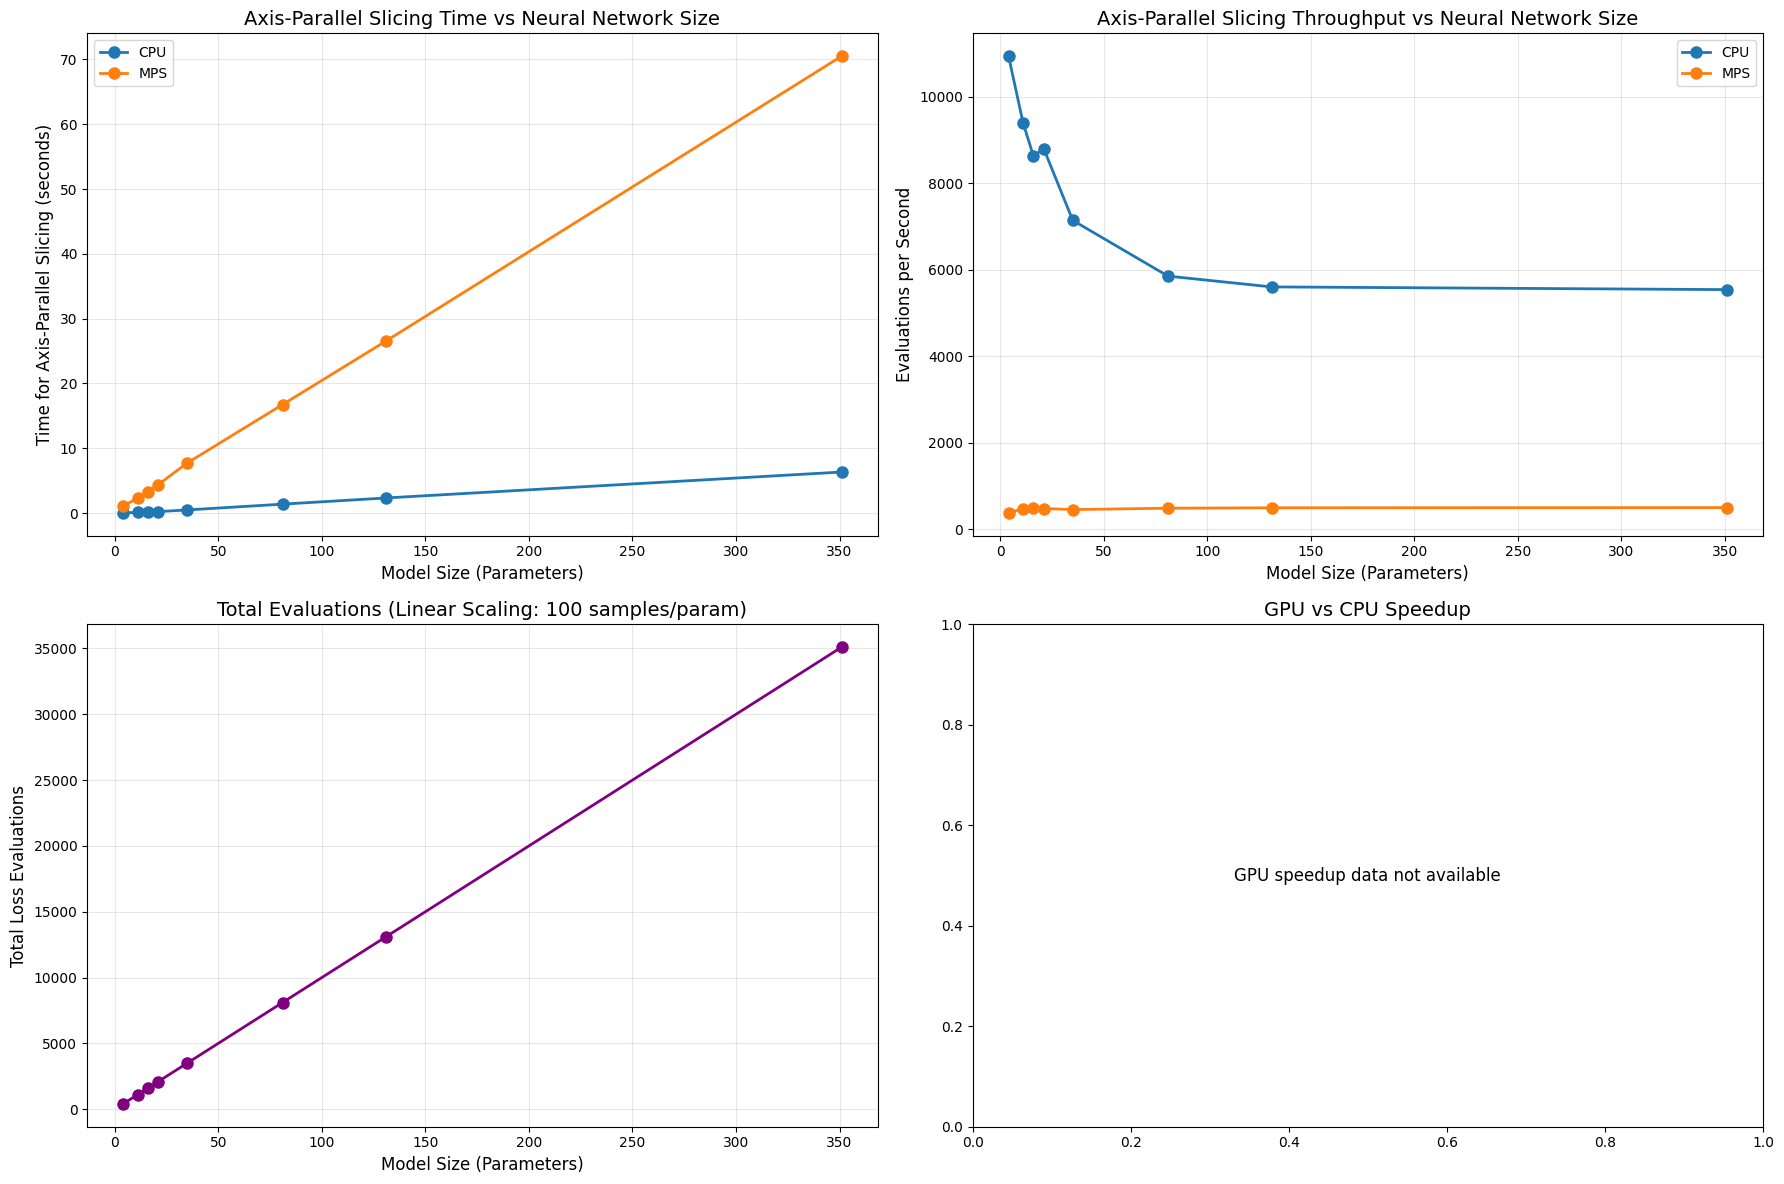

In [ ]:
# Plot results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Time vs Model Size
for device in devices:
    device_data = [r for r in results if r['device'] == device]
    x = [r['params'] for r in device_data]
    y = [r['time'] for r in device_data]
    ax1.plot(x, y, 'o-', label=device.upper(), markersize=8, linewidth=2)

ax1.set_xlabel('Model Size (Parameters)')
ax1.set_ylabel('Time for Axis-Parallel Slicing (seconds)')
ax1.set_title('Axis-Parallel Slicing Time vs Neural Network Size')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluations per Second vs Model Size
for device in devices:
    device_data = [r for r in results if r['device'] == device]
    x = [r['params'] for r in device_data]
    y = [r['evaluations'] / r['time'] for r in device_data]
    ax2.plot(x, y, 'o-', label=device.upper(), markersize=8, linewidth=2)

ax2.set_xlabel('Model Size (Parameters)')
ax2.set_ylabel('Evaluations per Second')
ax2.set_title('Axis-Parallel Slicing Throughput vs Neural Network Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Total Evaluations vs Model Size (shows linear scaling)
device_data = [r for r in results if r['device'] == devices[0]]  # Use first device for this plot
x = [r['params'] for r in device_data]
y = [r['evaluations'] for r in device_data]
ax3.plot(x, y, 'o-', color='purple', markersize=8, linewidth=2)
ax3.set_xlabel('Model Size (Parameters)')
ax3.set_ylabel('Total Loss Evaluations')
ax3.set_title(f'Total Evaluations (Linear Scaling: {SAMPLES_PER_PARAMETER} samples/param)')
ax3.grid(True, alpha=0.3)

# Plot 4: Speedup comparison (only if both CPU and GPU data available)
if len(devices) > 1:
    cpu_data = [r for r in results if r['device'] == 'cpu']
    gpu_data = [r for r in results if r['device'] == 'cuda']
    
    if len(cpu_data) == len(gpu_data):
        speedup = [cpu_data[i]['time'] / gpu_data[i]['time'] for i in range(len(cpu_data))]
        x = [r['params'] for r in cpu_data]
        ax4.plot(x, speedup, 'o-', color='green', markersize=8, linewidth=2)
        ax4.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No speedup')
        ax4.set_xlabel('Model Size (Parameters)')
        ax4.set_ylabel('Speedup (CPU time / GPU time)')
        ax4.set_title('GPU vs CPU Speedup for Axis-Parallel Slicing')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Add text annotations for speedup values
        for i, (param, speed) in enumerate(zip(x, speedup)):
            ax4.annotate(f'{speed:.1f}x', (param, speed), 
                        textcoords="offset points", xytext=(0,10), ha='center')
    else:
        ax4.text(0.5, 0.5, 'GPU speedup data not available', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('GPU vs CPU Speedup')
else:
    ax4.text(0.5, 0.5, 'Only CPU data available', 
            ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('GPU vs CPU Speedup')

plt.tight_layout()
plt.show()

## Performance Summary

Here's a detailed breakdown of the axis-parallel slicing performance results:

In [ ]:
# Print detailed summary
print("=" * 70)
print("AXIS-PARALLEL SLICING PERFORMANCE SUMMARY")
print("=" * 70)

for device in devices:
    device_data = [r for r in results if r['device'] == device]
    print(f"\n{device.upper()} Results:")
    print("-" * 50)
    for r in device_data:
        evals_per_sec = r['evaluations'] / r['time']
        print(f"  {r['model']:10s}: {r['params']:3d} params, {r['evaluations']:5,d} evals, {evals_per_sec:6.1f} evals/sec ({r['time']:5.2f}s)")

# Calculate and display speedup summary
if len(devices) > 1:
    print("\nSPEEDUP ANALYSIS:")
    print("-" * 50)
    cpu_data = [r for r in results if r['device'] == 'cpu']
    gpu_data = [r for r in results if r['device'] == 'cuda']
    
    if len(cpu_data) == len(gpu_data):
        total_speedup = [cpu_data[i]['time'] / gpu_data[i]['time'] for i in range(len(cpu_data))]
        avg_speedup = np.mean(total_speedup)
        max_speedup = np.max(total_speedup)
        min_speedup = np.min(total_speedup)
        
        print(f"  Average GPU speedup: {avg_speedup:.1f}x")
        print(f"  Maximum GPU speedup: {max_speedup:.1f}x")
        print(f"  Minimum GPU speedup: {min_speedup:.1f}x")
        
        if avg_speedup > 1:
            print(f"  → GPU is {avg_speedup:.1f}x faster on average")
        else:
            print(f"  → CPU is {1/avg_speedup:.1f}x faster on average")

# Scaling analysis
print(f"\nSCALING ANALYSIS:")
print("-" * 50)
device_data = [r for r in results if r['device'] == devices[0]]  # Use first device
params = [r['params'] for r in device_data]
times = [r['time'] for r in device_data]
evals = [r['evaluations'] for r in device_data]

# Check if time scales linearly with evaluations (and thus parameters)
if len(device_data) >= 2:
    time_per_eval = [t/e for t, e in zip(times, evals)]
    avg_time_per_eval = np.mean(time_per_eval)
    std_time_per_eval = np.std(time_per_eval)
    
    print(f"  Average time per evaluation: {avg_time_per_eval*1000:.3f} ms")
    print(f"  Std deviation: {std_time_per_eval*1000:.3f} ms")
    print(f"  Coefficient of variation: {(std_time_per_eval/avg_time_per_eval)*100:.1f}%")
    
    if (std_time_per_eval/avg_time_per_eval) < 0.2:
        print(f"  → Time scales approximately linearly with number of parameters")
    else:
        print(f"  → Time scaling shows some non-linear behavior")

print(f"\nTest completed with {SAMPLES_PER_PARAMETER} samples per parameter.")
print(f"Total evaluations ranged from {min(evals):,} to {max(evals):,}.")

AXIS-PARALLEL SLICING PERFORMANCE SUMMARY

CPU Results:
--------------------------------------------------
  4 params  :   4 params,   400 evals, 10934.1 evals/sec ( 0.04s)
  8 params  :  11 params, 1,100 evals, 9391.4 evals/sec ( 0.12s)
  12 params :  16 params, 1,600 evals, 8625.1 evals/sec ( 0.19s)
  20 params :  21 params, 2,100 evals, 8793.7 evals/sec ( 0.24s)
  32 params :  35 params, 3,500 evals, 7137.7 evals/sec ( 0.49s)
  72 params :  81 params, 8,100 evals, 5849.3 evals/sec ( 1.38s)
  156 params: 131 params, 13,100 evals, 5600.2 evals/sec ( 2.34s)
  372 params: 351 params, 35,100 evals, 5537.0 evals/sec ( 6.34s)

MPS Results:
--------------------------------------------------
  4 params  :   4 params,   400 evals,  375.6 evals/sec ( 1.06s)
  8 params  :  11 params, 1,100 evals,  476.0 evals/sec ( 2.31s)
  12 params :  16 params, 1,600 evals,  493.1 evals/sec ( 3.24s)
  20 params :  21 params, 2,100 evals,  477.0 evals/sec ( 4.40s)
  32 params :  35 params, 3,500 evals,  452.1